# Transformers 术语

## input IDS

LLM 唯一必须的输入是 input ids，本质是 tokens 索引（token indices in tokenizer vocabulary），即数字 ID 数组，从而符合模型输入的要求。
- 将输入文本序列转换成 input ids，即输入编码过程，数值对应的是 tokenizer 词汇表中的索引，




### Transformer 库实现了不同模型的 tokenizer。

下面代码展示了将输入序列转换成 tokens 和 input_ids 的结果。

In [5]:
from transformers import BertTokenizer

sequence = "A Titan RTX has 24GB of VRAM"
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

tokenized_sequence = tokenizer.tokenize(sequence) # 将输入序列转换成tokens
inputs = tokenizer(sequence) # 将输入序列转换成符合模型输入要求的input_ids,编码过程
"""

"""
encoded_sequence = inputs['input_ids']

print(tokenized_sequence)
print(encoded_sequence)
print("[INFO]: length of tokenized_sequence and  encoded_sequence:",len(tokenized_sequence),len(encoded_sequence))

['A', 'Titan', 'RT', '##X', 'has', '24', '##GB', 'of', 'VR', '##AM']
[101, 138, 28318, 56898, 12674, 10393, 10233, 32469, 10108, 74727, 36535, 102]
[INFO]: length of tokenized_sequence and  encoded_sequence: 10 12


### 映射
- 输出token对应的向量，即将词元 ID 转换为向量，即离散的数值表示。

In [6]:
token_ids = tokenizer.convert_tokens_to_ids(tokenized_sequence)
print(token_ids)

[138, 28318, 56898, 12674, 10393, 10233, 32469, 10108, 74727, 36535]


- 值得注意的是，调用 tokenizer() 函数返回的是字典对象，包含相应模型正常工作所需的所有参数，
- token indices 在键 input_ids 对应的键值中。
- 同时，tokenizer 会自动填充 "special tokens"（如果相关模型依赖它们），这也是 tokenized_sequence 和 encoded_sequence 列表中长度不一致的原因。

In [9]:
decoded_sequence = tokenizer.decode(encoded_sequence)
print(decoded_sequence[0])
print(decoded_sequence[-1])
print(decoded_sequence)

decoded_inputs_start = tokenizer.decode(inputs['input_ids'][0])
decoded_inputs_end = tokenizer.decode(inputs['input_ids'][-1])
print(decoded_inputs_start)
print(decoded_inputs_end)


[
]
[CLS] A Titan RTX has 24GB of VRAM [SEP]
[CLS]
[SEP]


### 查看tokenizer的词库


In [15]:
# 查看词表
print("Tokenizer 此表长度：",len(tokenizer.vocab.keys()))

from itertools import islice

for key,value in islice(tokenizer.vocab.items(),2):
    print(f"{key}:{value}")

Tokenizer 此表长度： 119547
[PAD]:0
[unused1]:1


## attention mask 注意力掩码

- 注意掩码（attention mask）是一个可选参数，一般在将输入序列进行批处理时使用。
- 作用是告诉我们哪些 tokens 应该被关注，哪些不用。
- 因为如果输入的序列是一个列表，每个序列长度是不一样的，通常是通过填充的方式把他们处理成同一长度。原始 token id 是我们需要关注的，填充的 id 是不用关注的。
- attention mask 是二进制张量类型，值为 1 的位置索引对应的原始 token 表示应该注意的值，而 0 表示填充值。

In [11]:
from transformers import AutoTokenizer
sentence_list = ["We are very happy to show you the 🤗 Transformers library.",  "Deepspeed is faster"]
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

padded_sequences = tokenizer(sentence_list,padding=True,return_tensors='pt')
print(padded_sequences['input_ids'])
print(padded_sequences['attention_mask'])

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tensor([[  101, 11312, 10320, 12495, 19308, 10114, 11391, 10855, 10103,   100,
         58263, 13299,   119,   102],
        [  101, 15526, 65998, 54436, 10127, 51524,   102,     0,     0,     0,
             0,     0,     0,     0]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])


In [12]:
print(padded_sequences)

{'input_ids': tensor([[  101, 11312, 10320, 12495, 19308, 10114, 11391, 10855, 10103,   100,
         58263, 13299,   119,   102],
        [  101, 15526, 65998, 54436, 10127, 51524,   102,     0,     0,     0,
             0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])}


## eop_token,pad_token,bos_token,eos_token

我们在模型的 checkpoints 目录下的配置文件中，经常能看到 eop_token、pad_token、bos_token、eos_token 这些与文本序列处理相关的特殊 token，它们代表的意义如下:

- bos_token（开始标记）：它表示文本序列的起始位置。在某些文本生成任务中，可能需要在序列的开头添加一个开始标记，以指示生成文本的起始点。
- eop_token（结束标记）：它表示文本序列的结束位置。在某些文本生成任务中，可能需要在序列中指定一个结束标记以表示文本的结束。
- pad_token（填充标记）：它用于将文本序列填充到相同长度时使用的特殊 token。在处理变长文本序列时，较短的序列可能需要通过添加填充标记来与较长的序列对齐。填充标记通常是一个特殊的 token，用于填充序列中的空白位置，使得所有序列具有相同的长度。

## decoder models

decoder 模型也称为自回归（auto-regressive）模型、causal language models，其按顺序阅读输入文本并必须预测下一个单词，在训练中会阅读添加掩码的句子。

## 架构与参数
- Checkpoints：给定架构中会被加载的权重。

# Transformers 功能

- Transformers 库提供创建 transformer 模型和加载使用共享模型的功能；
- 另外，模型中心（hub）包含数千个可以任意下载和使用的预训练模型，也支持用户上传模型到 Hub


Transformers 库的 API 主要包括以下三种：

- MAIN CLASSES：主要包括配置(configuration)、模型(model)、分词器(tokenizer)和流水线(pipeline)这几个最重要的类。
- MODELS：库中和每个模型实现有关的类和函数。
- INTERNAL HELPERS：内部使用的工具类和函数。

# try

## transformer 模型类别

Transformer 模型架构主要由两个部件组成：

- Encoder (左侧): 编码器接收输入并构建其表示（其特征）。这意味着对模型进行了优化，以从输入中获得理解。
- Decoder (右侧): 解码器使用编码器的表示（特征）以及其他输入来生成目标序列。这意味着该模型已针对生成输出进行了优化。

In [2]:
from IPython.display import Image

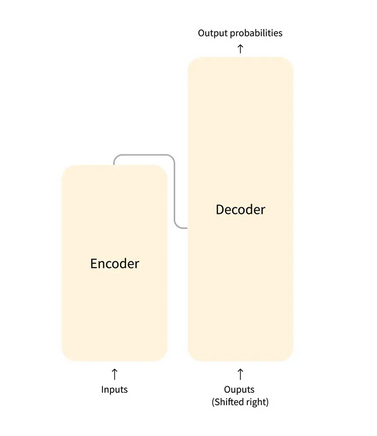

In [4]:
Image(filename="./image/encoder_decoder.png",width=300)

上述两个部件中的每一个都可以作为模型架构独立使用，具体取决于任务：

- <b>Encoder-only models</b>: 也叫自动编码 Transformer 模型，如 BERT-like 系列模型，适用于需要理解输入的任务。如句子分类和命名实体识别。
- <b>Decoder-only models</b>: 也叫自回归 Transformer 模型，如 GPT-like 系列模型。适用于生成任务，如文本生成。
- <b>Encoder-decoder models 或者 sequence-to-sequence models</b>: 也被称作序列到序列的 Transformer 模型，如 BART/T5-like 系列模型。适用于需要根据输入进行生成的任务，如翻译或摘要。

下表总结了目前的 transformers 架构模型类别、示例以及适用任务：

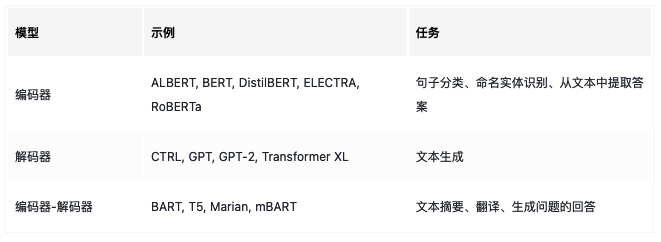

In [6]:
Image(filename="./image/transformers_model.png",width=600)

## Pipeline

Transformers 库支持通过 pipeline() 函数设置 task 任务类型参数，来跑通不同模型的推理，可实现一行代码跑通跨不同模态的多种任务，其支持的任务列表如下：

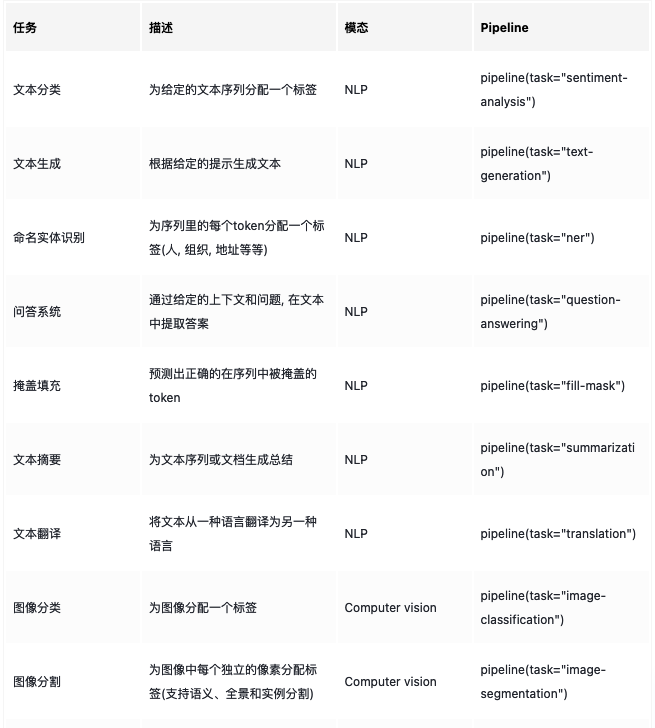

In [7]:
Image(filename="./image/pipline_1.png",width=600)

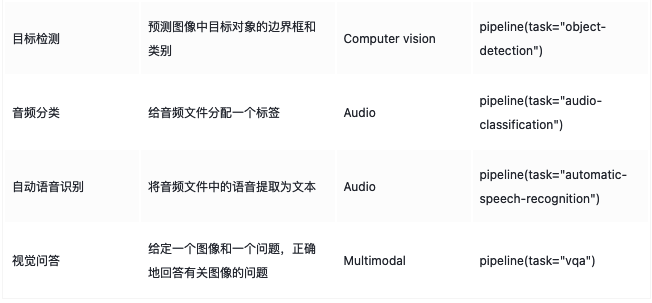

In [9]:
Image(filename="./image/pipline_2.png",width=600)

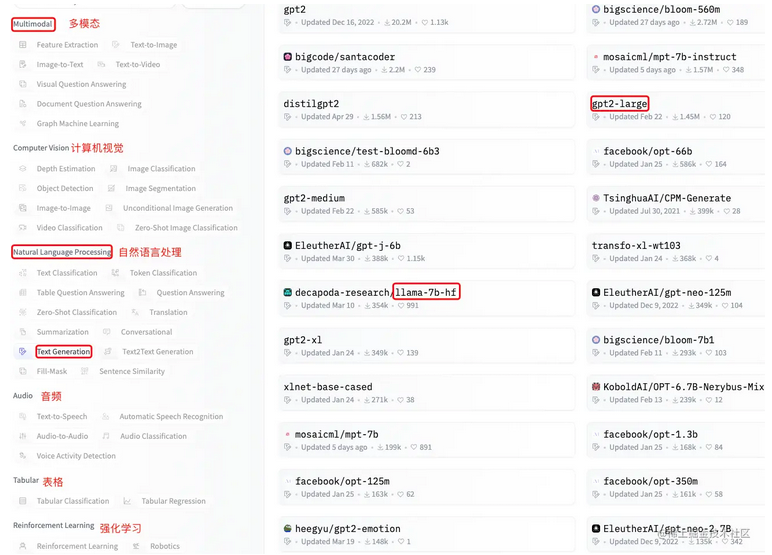

In [10]:
Image(filename="./image/pipline_3.png",width=600)

以下代码是通过 pipeline 函数实现对文本的情绪分类。

In [11]:
from transformers import pipeline
classifier = pipeline("sentiment-analysis")
print(classifier("I've been waiting for a HuggingFace course my whole life."))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

## AutoClass 简化了模型的加载

- Pipeline() 函数背后实际是通过 “AutoClass” 类，实现通过预训练模型的名称或路径自动查找其架构的快捷方式。
- 通过为任务选择合适的 AutoClass 和它关联的预处理类，来重现使用 pipeline() 的结果。

使用Auto Classes不需要知道模型是BERT、RoBERTa还是其他。AutoModel或AutoTokenizer会自动检查模型的配置文件 (config.json)，发现这是一个 BERT 架构，然后内部调用 BertModel相关逻辑加载。

- AutoModel: 自动加载预训练模型。
- AutoTokenizer: 自动加载对应的分词器。
- AutoConfig: 自动加载模型的配置（如隐藏层大小、注意力头数等）。
- AutoModelForSequenceClassification: 自动加载用于文本分类任务的模型（会自动选择BertForSequenceClassification,RobertaForSequenceClassification等）。
- AutoModelForQuestionAnswering: 自动加载用于问答任务的模型。
- AutoModelForCausalLM: 自动加载用于因果语言建模（如文本生成）的模型。

In [ ]:
from transformers import AutoModel, AutoTokenizer

model_name = "bert-base-uncased"  # 或 "roberta-base", "google/flan-t5-base"

# 使用 AutoModel 和 AutoTokenizer
model = AutoModel.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

### AutoTokenizer

- <b>分词器（tokenizer）</b>的作用是负责预处理文本，将输入文本（input prompt）转换为数字数组（array of numbers）来作为模型的输入。
- <b>tokenization 过程主要的规则包括</b>：
  - 如何拆分单词和什么样级别的单词应该被拆分
  - 值得注意的是，实例化 tokenizer 和 model 必须是同一个模型名称或者 checkpoints 路径。
- <b>对于 LLM ，通常还是使用 AutoModel 和 AutoTokenizer 来加载预训练模型和它关联的分词器。</b>

In [2]:
from transformers import AutoTokenizer
# 一般使用AutoTokenizer import AutoTokenizer


model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

encoded_sentences = tokenizer("We are very happy to show you the 🤗 Transformers library.")
print(encoded_sentences)

{'input_ids': [101, 11312, 10320, 12495, 19308, 10114, 11391, 10855, 10103, 100, 58263, 13299, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


tokenizer 的返回是包含了如下“键”的字典：

- input_ids: 用数字表示的 token。
- attention_mask: 应该关注哪些 token 的指示。

tokenizer() 函数还支持列表作为输入，并可填充和截断文本, 返回具有统一长度的批次：

In [ ]:
pt_batch = tokenizer(
    ["We are very happy to show you the 🤗 Transformers library.", "We hope you don't hate it."],
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors='pt',
)

## AutoModel 

- Transformers 提供了一种简单统一的方式来加载预训练的模型实例，即可以像加载 AutoTokenizer 一样加载 AutoModel，
- 我们所需要提供的必须参数只有模型名称或者 checkpoints 路径，即只需输入初始化的 checkpoint(检查点)或者模型名称就可以返回正确的模型体系结构。示例代码如下所示:

In [3]:
from transformers import AutoTokenizer,AutoModelForSequenceClassification
from torch import nn

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

pt_batch = tokenizer(
    "We are very happy to show you the 🤗 Transformers library.", "We hope you don't hate it.",
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors='pt',
)
pt_model = AutoModelForSequenceClassification.from_pretrained(model_name)
outputs = pt_model(**pt_batch) # **可解包pt_batch字典
predictions = nn.functional.softmax(outputs.logits,dim=-1) # 在logits上应用softmaxmax函数

print(predictions)
print(pt_model.config.id2label)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tensor([[0.0056, 0.0051, 0.0247, 0.2339, 0.7307]], grad_fn=<SoftmaxBackward0>)
{0: '1 star', 1: '2 stars', 2: '3 stars', 3: '4 stars', 4: '5 stars'}


注意，Transformers 模型默认情况下需要多个句子，虽然这里输入是一个句子，但 tokenizer 不仅会将输入ID列表转换为张量，还在其顶部添加了一个维度。

## AutoConfig

AutoConfig配置控制器，决定AutoModel具体加载哪种架构，通过config.model_type匹配BertModel/GPT2Model等。

注：核心作用是为模型提供精确的架构参数和超参数设置。

### 同一接口加载不同模型配置

使用AutoConfig.from_pretrained传递不同的模型参数名，即可获取不同的类型的Config。

In [ ]:
bert_config = AutoConfig.from_pretrained("bert-base-uncased") # BertConfig
gpt_config = AutoConfig.from_pretrained("gpt2") # GPT2Config

### 2）定义模型结构

如层数、注意力头数、隐藏层维度

In [ ]:
config = AutoConfig.from_pretrained("bert-base-uncased")
print(config.num_hidden_layers)  # 12（BERT-base的层数）

# 修改默认配置：覆盖预训练模型的默认参数
config = AutoConfig.from_pretrained("bert-base-uncased", num_hidden_layers=6)
model = AutoModel.from_pretrained("bert-base-uncased", config=config)  # 加载6层BERT

## 其他类型的AutoModel

在Hugging Face Transformers库中，AutoModel 是一个通用模型加载器。针对特定任务也提供了不同的AutoModelForXXX（如AutoModelForSequenceClassification）。

### 与AutoModel的区别：
- AutoModel.from_pretrained("gpt2") → 只加载 GPT-2 的 Transformer 层，输出是 last_hidden_state（向量序列），没有预测下一个词的能力。
- AutoModelForCausalLM.from_pretrained("gpt2") → 在 GPT-2 主干基础上，额外加载一个 lm_head（语言模型头），能输出每个 token 的 logits（预测下一个词的概率），支持文本生成。

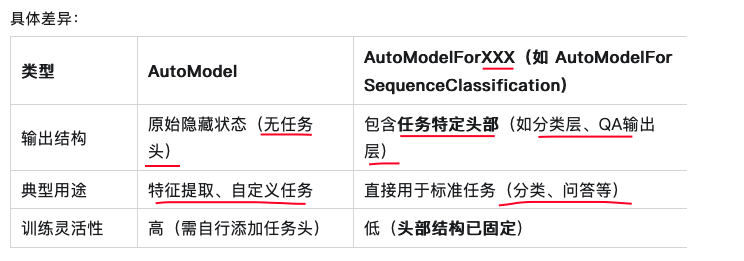

In [3]:
Image(filename="./image/automodel.png",width=600)

### 如何根据模型名称判断该用哪个AutoModel？
- 一般来讲如果模型是用于生成文本的（尤其是以 GPT、LLaMA 为架构的），就用 AutoModelForCausalLM。

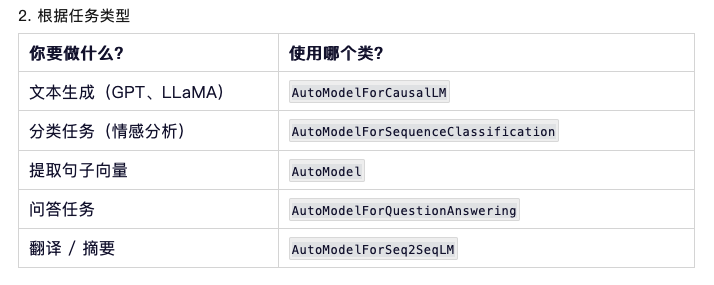

In [4]:
Image(filename="./image/whichmodel.png",width=600)

## trainer 简化 PyTorch 模型的训练、评估和推理

Trainer 是 Hugging Face transformers 库提供的一个 高级 API，用于 简化 PyTorch 模型的训练、评估和推理。它支持：

- 自动批量训练
- 多 GPU 训练
- 自动梯度累积
- 混合精度训练
- 模型评估
- 与 datasets 兼容的数据加载

### 为什么使用 Trainer？

在 PyTorch 中，通常需要手动编写完整的训练循环:

In [ ]:
for epoch in range(num_epochs):
    for batch in dataloader:
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = loss_fn(outputs,batch['labels'])
        loss.backward()
        optimizer.step()

而 Trainer 只需几行代码即可完成训练：
- 它封装了pytorch训练循环，是代码更简洁和易用

In [ ]:
from transformers import Trainer
trainer = Trainer(model=model,args=training_args,train_dataset=train_dataset)
trainer.train()

### Trainer 的基本用法

#### 加载预训练模型：

In [ ]:
from transformers import BertTokenizer,BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')

#### 加载数据集：
- 使用datasets库加载数据集


In [ ]:
form datasets import load_dataset
dataset = load_dataset('imdb')

数据格式：


In [ ]:
{'text': 'This movie is great!', 'label': 1}

#### 数据预处理
- 使用tokenizer对文本进行编码

In [ ]:
def preprocess(example):
    return tokenizer(example['text'],padding='max_lenght',truncation=True)

encoded_dataset = dataset.map(preprocess,batched=True)

将数据转换为pytorch格式：

In [ ]:
encoded_dataset.set_format(type='torch',columns=["input_ids", "attention_mask", "label"])

#### 设置TrainingArguments 用于配置训练参数

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",  # 每个 epoch 评估一次
    save_strategy="epoch",        # 每个 epoch 保存一次
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,           # 训练 3 轮
    logging_dir="./logs",         # 记录日志
    logging_steps=10,             # 每 10 步记录一次 loss
    save_total_limit=2,           # 最多保留 2 个模型检查点
)


#### 创建Trainer

In [ ]:
from  transformers import Trainer
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = encoded_dataset['train'],
    eval_dataset = encoded_dataset['test'],
)

#### 训练模型

In [ ]:
trainer.train()

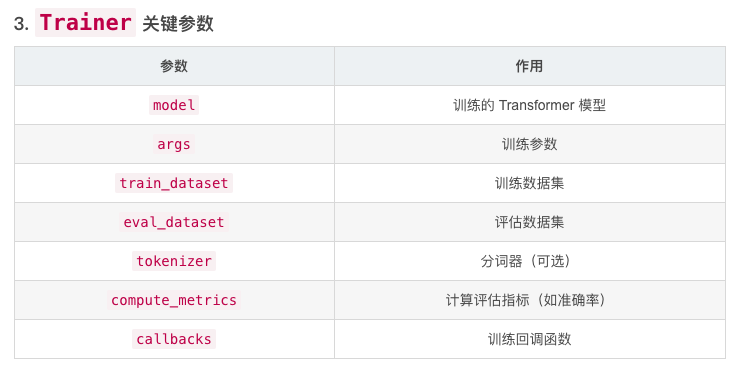

In [16]:
Image(filename="./image/train_p.png",width=600)

#### 评估模型
- 训练完成后，可以使用 evaluate() 进行评估：

In [ ]:
trainer.evaluate()

如果要自定义评估指标：


In [ ]:
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    compute_metrics=compute_metrics,
)


#### 预测（推理）

训练完成后，可以使用predict()进行预测：

In [ ]:
predictions = trainer.predict(encoded_dataset['test'])
print(predictions)

提取类别：

In [ ]:
import torch

predicted_labels = torch.argmax(torch.tensor(predictions.predictions), dim=1)
print(predicted_labels)

#### 保存和加载模型

In [ ]:
trainer.save_model('./trainer_model') # 保存模型

#### 加载已保存的模型

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained('./trainer_model')

#### 多GPU训练

如果有多个GPU，可以使用

In [ ]:
accelerate launch train.py

或则在TrainingArguments里开启fp16进行混合精度训练：

In [ ]:
training_args = TrainerArguments(
    output_dir = './results',
    per_device_train_batch_size = 8,
    fp16=True, # 启用混合精度训练
)